In [ ]:
from astropy.io import fits
import healpy as hp
import numpy as np
nside = 1024
dfg = fits.open('/mnt/ceph/users/spandey/GODMAX/notebooks/all_arxiv/mock_gen/sdss_data/galaxy_DR12v5_CMASS_North.fits.gz')
ra_g, dec_g, z_g = dfg[1].data['RA'], dfg[1].data['DEC'], dfg[1].data['Z']
indsel = np.where((z_g > 0.4) & (z_g < 0.7))[0]
ra_g, dec_g, z_g = ra_g[indsel], dec_g[indsel], z_g[indsel]
print(len(ra_g))
mapg   = np.zeros((hp.nside2npix(nside)))
pix = hp.ang2pix(nside, ra_g, dec_g, lonlat=True)
weight = 1. #1 for number density, array of size(x) for arbitrary
np.add.at(mapg, pix, weight)  

dfg = fits.open('/mnt/ceph/users/spandey/GODMAX/notebooks/all_arxiv/mock_gen/sdss_data/galaxy_DR12v5_CMASS_South.fits.gz')
ra_g, dec_g, z_g = dfg[1].data['RA'], dfg[1].data['DEC'], dfg[1].data['Z']
indsel = np.where((z_g > 0.4) & (z_g < 0.7))[0]
ra_g, dec_g, z_g = ra_g[indsel], dec_g[indsel], z_g[indsel]
print(len(ra_g))
# mapg   = np.zeros((hp.nside2npix(nside)))
pix = hp.ang2pix(nside, ra_g, dec_g, lonlat=True)
weight = 1. #1 for number density, array of size(x) for arbitrary
np.add.at(mapg, pix, weight)  

# df = fits.open('/mnt/ceph/users/spandey/GODMAX/notebooks/all_arxiv/mock_gen/sdss_data/random1_DR12v5_CMASS_South.fits.gz')
df = fits.open('/mnt/ceph/users/spandey/GODMAX/data/sdss/random1_DR12v5_CMASS_North.fits.gz')
ra_rand, dec_rand, z_rand = df[1].data['RA'], df[1].data['DEC'], df[1].data['Z']

# mask = np.zeros(12*nside**2)
# pix = hp.ang2pix(nside, ra_rand, dec_rand, lonlat=True)
# mask[pix] = 1
# ind_unmask = np.where(mask == 1)[0]



gal_count_unmask = mapg[ind_unmask]
mean_gal_count = np.mean(gal_count_unmask)
delta_g_data = (mapg / mean_gal_count) - 1


df = hp.read_map('/mnt/home/spandey/ceph/GODMAX/data/NILC_ymap_rotated_celestial_DES_coords.fits')
ymap_data = hp.ud_grade(df, nside_out=nside)


import pymaster as nmt
f_g = nmt.NmtField(mask, [delta_g_data])
f_y = nmt.NmtField(mask, [ymap_data])
b = nmt.NmtBin.from_nside_linear(nside, 64)
cl_gy_data = nmt.compute_full_master(f_g, f_y, b)[0]





In [58]:
from astropy.io import fits
import healpy as hp
import numpy as np
nside = 1024

ldir = '/mnt/ceph/users/spandey/GODMAX/notebooks/all_arxiv/mock_gen/sdss_data'

dfg = fits.open(f'{ldir}/galaxy_DR12v5_CMASS_North.fits.gz')
ra_g1, dec_g1, z_g1 = dfg[1].data['RA'], dfg[1].data['DEC'], dfg[1].data['Z']
w_g1 = dfg[1].data['WEIGHT_SYSTOT']

dfg = fits.open(f'{ldir}/galaxy_DR12v5_CMASS_South.fits.gz')
ra_g2, dec_g2, z_g2 = dfg[1].data['RA'], dfg[1].data['DEC'], dfg[1].data['Z']
w_g2 = dfg[1].data['WEIGHT_SYSTOT']

z_g = np.concatenate((z_g1, z_g2))
zmin = 0.4
zmax = 0.8
indsel = np.where((z_g > zmin) & (z_g < zmax))[0]

z_g = z_g[indsel]
ra_g = np.concatenate((ra_g1, ra_g2))[indsel]
dec_g = np.concatenate((dec_g1, dec_g2))[indsel]
w_g = np.concatenate((w_g1, w_g2))[indsel]


z_array = np.linspace(0, 1.5, 200)
z_centers = 0.5 * (z_array[1:] + z_array[:-1])

hist_z = np.histogram(z_g, bins=z_array, density=True)[0]

# print(dfg[1].header)




In [12]:
df = fits.open(f'{ldir}/random1_DR12v5_CMASS_South.fits.gz')
ra_rand1, dec_rand1, z_rand1 = df[1].data['RA'], df[1].data['DEC'], df[1].data['Z']
w_rand1 = np.ones_like(ra_rand1)


df = fits.open(f'{ldir}/random1_DR12v5_CMASS_North.fits.gz')
ra_rand2, dec_rand2, z_rand2 = df[1].data['RA'], df[1].data['DEC'], df[1].data['Z']
w_rand2 = np.ones_like(ra_rand2)

ra_rand = np.concatenate((ra_rand1, ra_rand2))
dec_rand = np.concatenate((dec_rand1, dec_rand2))
z_rand = np.concatenate((z_rand1, z_rand2))
w_rand = np.concatenate((w_rand1, w_rand2))




In [59]:
import pymaster as nmt
ipix = hp.ang2pix(nside, ra_g, dec_g, lonlat=True)
npix = hp.nside2npix(nside)

nmap = np.bincount(ipix, minlength=npix, weights=w_g)

ipix_rand = hp.ang2pix(nside, ra_rand, dec_rand, lonlat=True)
npix_rand = hp.nside2npix(nside)

nmap_rand = np.bincount(ipix_rand, minlength=npix_rand)

lmax = 3*nside -1 
b = nmt.NmtBin.from_lmax_linear(lmax, nlb=100)
leff = b.get_effective_ells()

f_cat = nmt.NmtFieldCatalogClustering(np.array([ra_g, dec_g]), w_g, np.array([ra_rand, dec_rand]), w_rand, lmax=lmax, lonlat=True)
w_cat = nmt.NmtWorkspace.from_fields(f_cat, f_cat, b)
pcl = nmt.compute_coupled_cell(f_cat, f_cat)
cl_cat = w_cat.decouple_cell(pcl)




In [60]:
# mask = hp.ud_grade(np., nside_out=nside)
mask = np.clip(nmap_rand, 0, 1)
nbar = np.sum(nmap)/np.sum(mask)
nbar_map = nbar * mask
# Avoid division by zero below
good = mask > 0
delta = np.zeros(npix)
delta[good] = nmap[good]/nbar_map[good]-1

# Now create a NaMaster field
f_pix = nmt.NmtField(mask, [delta], n_iter=0)

wpix = nmt.NmtWorkspace.from_fields(f_pix, f_pix, b)

pcl = nmt.compute_coupled_cell(f_pix, f_pix)
cl = wpix.decouple_cell(pcl)

pnl = 4*np.pi*np.mean(mask)/(npix*nbar)
nl = wpix.decouple_cell(pnl*np.ones_like(pcl))

cl_pix = cl-nl


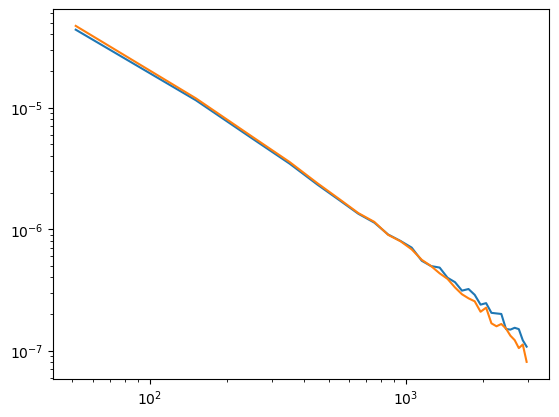

In [61]:
pl.figure()
pl.plot(leff, cl_cat[0])
pl.plot(leff, cl_pix[0])
pl.xscale('log')
pl.yscale('log')


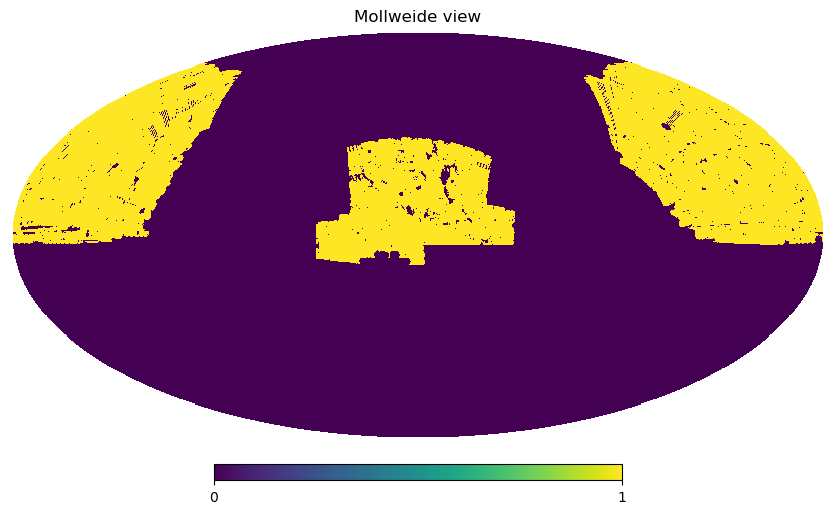

In [15]:
hp.mollview(np.clip(nmap_rand, 0, 1))



In [62]:
df = hp.read_map('/mnt/ceph/users/spandey/GODMAX/data/NILC_ymap_rotated_celestial_DES_coords.fits')
ymap_data = hp.ud_grade(df, nside_out=nside)
mask = np.clip(nmap_rand, 0, 1)
f_y = nmt.NmtField(mask, [ymap_data])
w_gy = nmt.NmtWorkspace.from_fields(f_pix, f_y, b)
pcl_gy = nmt.compute_coupled_cell(f_pix, f_y)
cl_gy = w_gy.decouple_cell(pcl_gy)




(50, 1800)

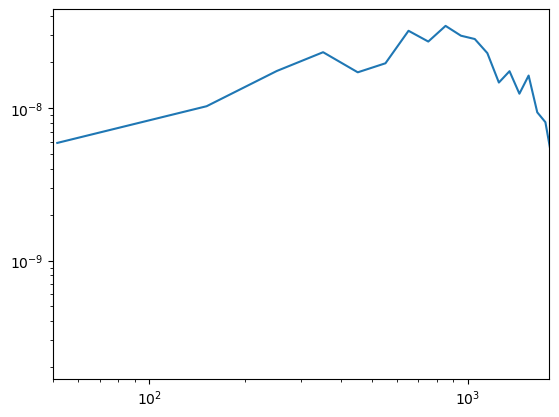

In [63]:
fac = leff*(leff+1)/(2*np.pi)
pl.figure()
pl.plot(leff, fac*cl_gy[0])
# pl.plot(leff, cl_pix[0])
pl.xscale('log')
pl.yscale('log')
pl.xlim(50,1800)


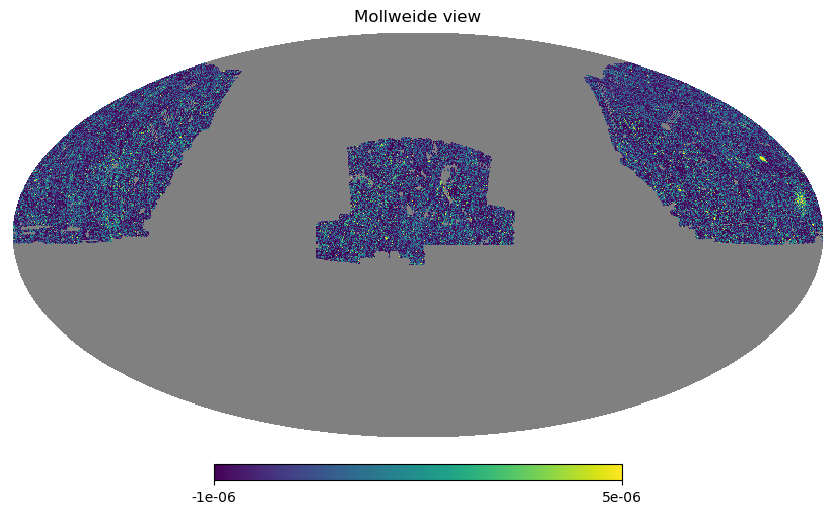

In [64]:
# hp.mollview(ymap_data*mask)
ymap_toplot = ymap_data*mask
ind_masked = np.where(mask==0)[0]
ymap_toplot[ind_masked] = hp.UNSEEN
hp.mollview(ymap_toplot, min=-1e-6, max=5e-6)


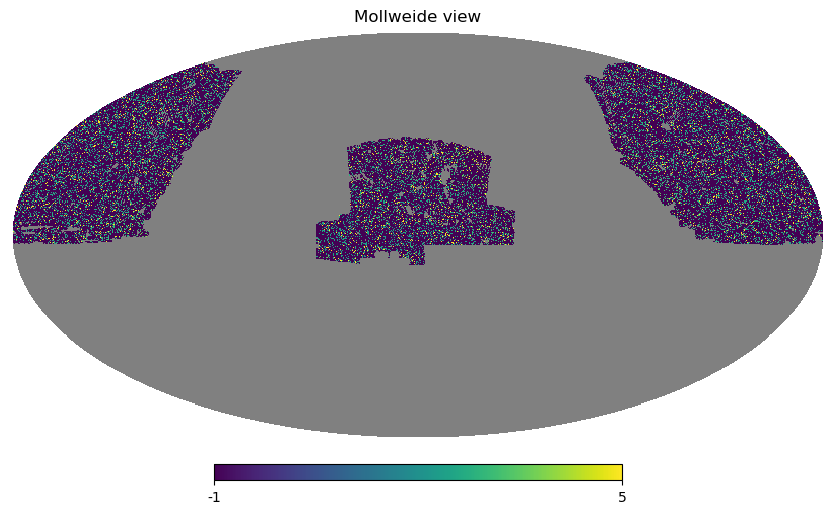

In [65]:
# hp.mollview(ymap_data*mask)
delta_toplot = delta*mask
ind_masked = np.where(mask==0)[0]
delta_toplot[ind_masked] = hp.UNSEEN
hp.mollview(delta_toplot, min=-1, max=5)


In [66]:
# ymap_toplot
mask

array([0, 0, 0, ..., 0, 0, 0])

In [67]:
w_yy = nmt.NmtWorkspace.from_fields(f_y, f_y, b)
pcl_yy = nmt.compute_coupled_cell(f_y, f_y)
cl_yy = w_yy.decouple_cell(pcl_yy)



(50, 1800)

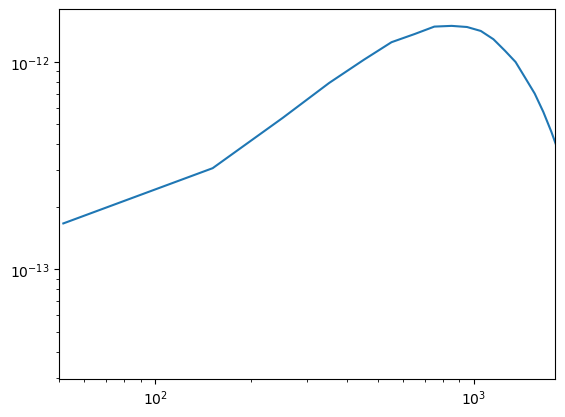

In [68]:
fac = leff*(leff+1)/(2*np.pi)
pl.figure()
pl.plot(leff, fac*cl_yy[0])
# pl.plot(leff, cl_pix[0])
pl.xscale('log')
pl.yscale('log')
pl.xlim(50,1800)




In [73]:
import pickle as pk
saved = {'zcen':z_centers, 'nz':hist_z, 'zmin':zmin, 'zmax':zmax, 'Ngal':len(ra_g), 'leff':leff, 'cl_gg':cl_cat[0], 'nl_gg':nl[0], 'cl_gy':cl_gy[0], 'cl_yy':cl_yy[0]}
pk.dump(saved, open('measure_cmass_planck.pk','wb'))




Text(0, 0.5, '$n(z)$')

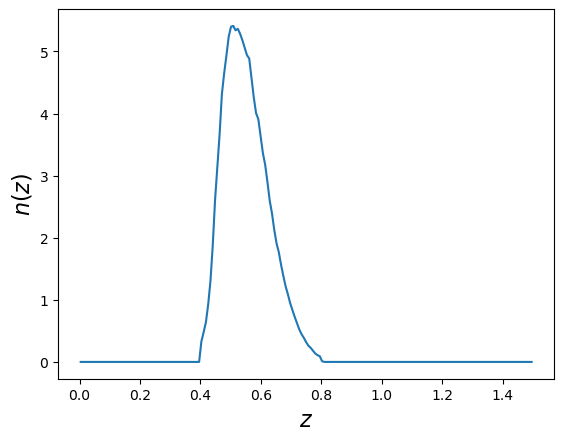

In [71]:
import matplotlib.pyplot as pl
pl.figure()
pl.plot(z_centers, hist_z)
pl.xlabel(r'$z$', fontsize=16)
pl.ylabel(r'$n(z)$', fontsize=16)